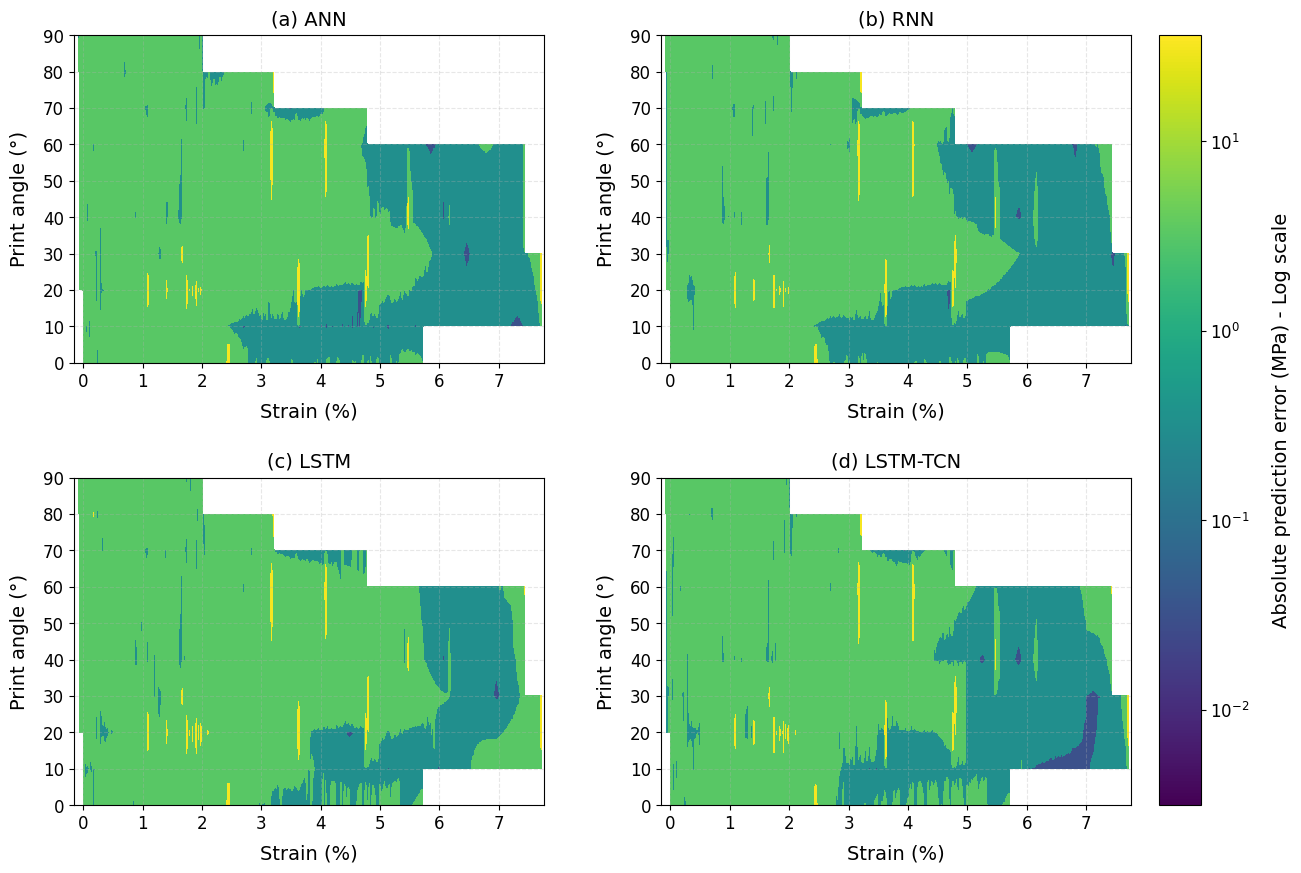

Saved: ./noTL_combined_fig/noTL_models_error_contour_2x2_shared_cbar.png
LogNorm vmin=3.130e-03, vmax=3.631e+01


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker

# 1) 路径配置（按之前保存的位置）
roots = {
    'ANN':      './noTL_docs/ann',
    'RNN':      './noTL_docs/rnn',
    'LSTM':     './noTL_docs/lstm',
    'LSTM-TCN': './noTL_docs/lstmtcn',
}
npz_names = {
    'ANN': 'ann_grids.npz',
    'RNN': 'rnn_grids.npz',
    'LSTM': 'lstm_grids.npz',
    'LSTM-TCN': 'lstmtcn_grids.npz',
}

# 2) 加载数据（优先 npz，缺失则回退到 .npy）
def load_grids(root_dir: str, npz_name: str):
    npz_path = os.path.join(root_dir, npz_name)
    if os.path.exists(npz_path):
        z = np.load(npz_path)
        return z['strain_common'], z['angle_grid_dense'], z['final_grid_error']
    # fallback: 单独的 .npy 文件
    sc = np.load(os.path.join(root_dir, 'strain_common.npy'))
    ag = np.load(os.path.join(root_dir, 'angle_grid_dense.npy'))
    fe = np.load(os.path.join(root_dir, 'final_grid_error.npy'))
    return sc, ag, fe

loaded = {}
for name in ['ANN', 'RNN', 'LSTM', 'LSTM-TCN']:
    sc, ag, fe = load_grids(roots[name], npz_names[name])
    loaded[name] = {'strain': sc, 'angle': ag, 'grid': fe}

# 3) 统一对数色阶范围（忽略非正值）
mins_pos, maxs = [], []
for name, d in loaded.items():
    arr = d['grid']
    arr_pos = arr[arr > 0]
    if arr_pos.size > 0:
        mins_pos.append(arr_pos.min())
    maxs.append(np.nanmax(arr))
vmin = (min(mins_pos) if mins_pos else 1e-8)
vmax = max(maxs) if maxs else 1.0
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# 4) 画布与布局：保持图5原有子图尺寸（2×2 子图 + 右侧色条留白）
title_fs, label_fs, tick_fs, cbar_fs = 14, 14, 12, 14
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(right=0.88, wspace=0.25, hspace=0.35)

order = [
    ('ANN', '(a) ANN'),
    ('RNN', '(b) RNN'),
    ('LSTM', '(c) LSTM'),
    ('LSTM-TCN', '(d) LSTM-TCN'),
]

for ax, (name, label) in zip(axes.ravel(), order):
    s = loaded[name]['strain']
    a = loaded[name]['angle']
    z = np.ma.masked_invalid(loaded[name]['grid'])
    X, Y = np.meshgrid(s, a)  # X: Strain, Y: Angle
    # 小图标题放在框外正上方，不改变绘图区尺寸
    ax.text(0.5, 1.02, label, transform=ax.transAxes, ha='center', va='bottom', fontsize=title_fs, clip_on=False)
    ax.set_xlabel('Strain (%)', fontsize=label_fs, labelpad=8)
    ax.set_ylabel('Print angle (°)', fontsize=label_fs, labelpad=10)
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.grid(True, linestyle='--', alpha=0.3)
    # 模型名称仍放在图内右上角（不移到标题）
    ax.contourf(X, Y, z, levels=100, cmap='viridis', norm=norm)

# 5) 共享色条：列宽、刻度与风格与图8一致
sp = fig.subplotpars
cbar_ax = fig.add_axes([0.9, sp.bottom, 0.03, sp.top - sp.bottom])
mappable = ScalarMappable(cmap='viridis', norm=norm); mappable.set_array([])
cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    ticks=mticker.LogLocator(base=10.0),
    format=mticker.LogFormatterMathtext(base=10.0)
)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=cbar_fs, labelpad=16)
cbar.ax.tick_params(labelsize=tick_fs)
cbar.minorticks_off()

# 6) 保存
out_dir = './noTL_combined_fig'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'noTL_models_error_contour_2x2_shared_cbar.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}\nLogNorm vmin={vmin:.3e}, vmax={vmax:.3e}')

In [3]:
import numpy as np

# 误差分段统计（沿应变轴）
# 口径：
# - 使用与等高线相同的误差栅格（loaded[name]['grid']）
# - 排除白区（非有限值）
# - 排除 50° 的测试样本（该角度仅用于可视化插值，不参与统计）
# - 指标在原始绝对误差（MPa）上计算

models = ['ANN', 'RNN', 'LSTM', 'LSTM-TCN']

# 自动识别应变是否是百分数（>1 视为百分数），若你已有 percent_strain 变量，将以其为准
if 'percent_strain' in globals():
    use_percent = bool(percent_strain)
else:
    # 用任一模型的应变轴判断
    any_s = loaded[models[0]]['strain']
    use_percent = (np.nanmax(any_s) > 1.0)

thr1, thr2 = (5.0, 6.0) if use_percent else (0.05, 0.06)

# 分段定义（基于应变轴值）
def make_band_masks(strain_axis: np.ndarray):
    b1 = strain_axis < thr1
    b2 = (strain_axis >= thr1) & (strain_axis <= thr2)
    b3 = strain_axis > thr2
    return {'B1(<5%)' if use_percent else 'B1(<0.05)': b1,
            'B2(5–6%)' if use_percent else 'B2(0.05–0.06)': b2,
            'B3(>6%)' if use_percent else 'B3(>0.06)': b3}

# 角度 50° 剔除掩码（行方向）
# 注意：loaded[name]['grid'] 按绘图时的用法，形状与 np.meshgrid(s, a) 相匹配，即 (len(angle), len(strain))
angle_any = loaded[models[0]]['angle']
angle_exclude_mask = np.isclose(angle_any, 50.0, atol=1e-6)
angle_keep_mask = ~angle_exclude_mask  # True 表示保留
angle_keep_mask2d = angle_keep_mask[:, None]  # (n_angle, 1)

# 结果容器：bands × models → (A0.10%, median, P95)
results = {}

for name in models:
    s = loaded[name]['strain']          # (n_strain,)
    a = loaded[name]['angle']           # (n_angle,)
    Z = loaded[name]['grid']            # (n_angle, n_strain) 与 contourf 一致

    # 分段掩码（列方向：应变）
    band_masks = make_band_masks(s)

    # 有效数据掩码：排除白区（非有限值）
    valid_mask = np.isfinite(Z)

    # 排除 50° 行
    valid_mask &= angle_keep_mask2d

    # 逐分段统计
    for band_name, band_mask_1d in band_masks.items():
        # 列掩码扩展到二维
        band_mask2d = band_mask_1d[None, :]  # (1, n_strain)
        mask = valid_mask & band_mask2d

        vals = np.abs(Z[mask])
        if vals.size == 0:
            A010 = np.nan
            med = np.nan
            p95 = np.nan
        else:
            A010 = 100.0 * np.mean(vals <= 0.10)
            med = float(np.median(vals))
            p95 = float(np.percentile(vals, 95))

        results.setdefault(band_name, {})[name] = (A010, med, p95)

# 打印 3×4 表（行=分段，列=模型，每格为 A0.10(%), median(Pa), P95(MPa)）
col_order = models
row_order = list(results.keys())

# 头部
header = ["Band"] + col_order
print("\t".join(header))

for band in row_order:
    row_cells = [band]
    for m in col_order:
        A010, med, p95 = results[band].get(m, (np.nan, np.nan, np.nan))
        if np.isnan(A010) or np.isnan(med) or np.isnan(p95):
            cell = "—"
        else:
            cell = f"A0.10={A010:.1f}% | median={med:.3f} | P95={p95:.3f}"
        row_cells.append(cell)
    print("\t".join(row_cells))

# 如需后续使用为数值形式，也可将 results 返回或转为 DataFrame



Band	ANN	RNN	LSTM	LSTM-TCN
B1(<5%)	A0.10=0.4% | median=2.281 | P95=5.419	A0.10=0.1% | median=2.340 | P95=5.336	A0.10=0.1% | median=2.413 | P95=5.552	A0.10=0.1% | median=2.128 | P95=5.778
B2(5–6%)	A0.10=0.8% | median=0.726 | P95=1.836	A0.10=1.0% | median=0.578 | P95=1.735	A0.10=0.1% | median=1.074 | P95=1.790	A0.10=1.1% | median=0.537 | P95=1.184
B3(>6%)	A0.10=1.4% | median=0.492 | P95=0.969	A0.10=0.7% | median=0.577 | P95=1.084	A0.10=0.6% | median=0.743 | P95=2.183	A0.10=9.4% | median=0.392 | P95=1.597


In [7]:
import numpy as np
import pandas as pd

# === 分段误差统计：A0.50 / Median / P95 ===
# 依赖输入：
# - 四个误差栅格：E_ann, E_rnn, E_lstm, E_lstmtcn，形状 (n_angle, n_strain)，单位 MPa（绝对误差）
# - 角度轴：angle，形状 (n_angle,)
# - 应变轴：strain，形状 (n_strain,)
# - 百分形式标识：percent_strain (bool)；True 表示 0–7（百分数），False 表示 0.00–0.07（小数）
# - 可选有效掩码：mask_valid（同形状）True=有效；若缺省则仅用 isfinite 和角度排除
#
# 输出：
# - 长表 DataFrame：列为 [Band, Model, A0.50 (%), Median (MPa), P95 (MPa)]
# - 可选：宽表打印

# 若没有独立的 E_* 变量，则从 loaded 中构造以与前面图一致
if 'E_ann' not in globals():
    E_ann = loaded['ANN']['grid']
    E_rnn = loaded['RNN']['grid']
    E_lstm = loaded['LSTM']['grid']
    E_lstmtcn = loaded['LSTM-TCN']['grid']
    angle = loaded['ANN']['angle']
    strain = loaded['ANN']['strain']
    # 若未显式提供 percent_strain，则自动判断
    if 'percent_strain' not in globals():
        percent_strain = (np.nanmax(strain) > 1.0)

# 阈值与分段掩码（沿应变轴）
thr1, thr2 = (5.0, 6.0) if percent_strain else (0.05, 0.06)
B1_mask = strain < thr1
B2_mask = (strain >= thr1) & (strain <= thr2)
B3_mask = strain > thr2
band_defs = {
    'B1 (<5%)': B1_mask if percent_strain else (strain < thr1),
    'B2 (5 to 6%)': B2_mask if percent_strain else ((strain >= thr1) & (strain <= thr2)),
    'B3 (>6%)': B3_mask if percent_strain else (strain > thr2),
}

# 模型映射（名称 → 栅格）
model_to_grid = {
    'ANN': E_ann,
    'RNN': E_rnn,
    'LSTM': E_lstm,
    'LSTM TCN': E_lstmtcn,
}

# 角度 50° 行排除（若 angle 内无 50 则不会排除任何行）
angle_is_50 = np.isclose(angle.astype(float), 50.0, atol=1e-6)
keep_angle_row = ~angle_is_50  # True=保留
keep_angle_row_2d = keep_angle_row[:, None]

rows = []

for model_name, E in model_to_grid.items():
    if E is None:
        continue
    # 基础有效掩码：有限值
    valid = np.isfinite(E)
    # 合并外部有效掩码（可选）
    if 'mask_valid' in globals() and isinstance(mask_valid, np.ndarray) and mask_valid.shape == E.shape:
        valid &= mask_valid
    # 排除 50° 行
    if keep_angle_row.any():
        valid &= keep_angle_row_2d

    # 对三个分段逐一计算
    for band_name, band_mask_1d in band_defs.items():
        # 列方向（应变）掩码扩展
        band_mask_2d = band_mask_1d[None, :]
        sel = valid & band_mask_2d
        vals = np.abs(E[sel])
        if vals.size == 0:
            A050 = np.nan
            med = np.nan
            p95 = np.nan
        else:
            A050 = 100.0 * np.mean(vals <= 0.50)
            med = float(np.median(vals))
            p95 = float(np.percentile(vals, 95))
        rows.append({
            'Band': band_name,
            'Model': model_name,
            'A0.50 (%)': None if np.isnan(A050) else round(A050, 1),
            'Median (MPa)': None if np.isnan(med) else float(f"{med:.3f}"),
            'P95 (MPa)': None if np.isnan(p95) else float(f"{p95:.3f}"),
        })

# 生成长表
long_df = pd.DataFrame(rows, columns=['Band', 'Model', 'A0.50 (%)', 'Median (MPa)', 'P95 (MPa)'])

# 打印长表
print('\nSegmented error statistics (original absolute errors, excluding invalid & 50°):')
print(long_df.to_string(index=False))

# 可选：打印友好的宽表
try:
    wide_df = long_df.pivot(index='Band', columns='Model', values=['A0.50 (%)', 'Median (MPa)', 'P95 (MPa)'])
    # 为展示清爽，列多级名拼接
    wide_df.columns = [f"{lvl2} | {lvl1}" for lvl1, lvl2 in wide_df.columns]
    wide_df = wide_df.reindex(index=['B1 (<5%)', 'B2 (5 to 6%)', 'B3 (>6%)'])
    print('\nWide view (rows=Band, columns=Model | Metric):')
    print(wide_df.to_string())
except Exception as e:
    print('\n[Info] Wide view not printed:', e)



Segmented error statistics (original absolute errors, excluding invalid & 50°):
        Band    Model  A0.50 (%)  Median (MPa)  P95 (MPa)
    B1 (<5%)      ANN        7.6         2.281      5.419
B2 (5 to 6%)      ANN       24.4         0.726      1.836
    B3 (>6%)      ANN       51.2         0.492      0.969
    B1 (<5%)      RNN        7.2         2.340      5.336
B2 (5 to 6%)      RNN       43.8         0.578      1.735
    B3 (>6%)      RNN       29.8         0.577      1.084
    B1 (<5%)     LSTM        3.0         2.413      5.552
B2 (5 to 6%)     LSTM        8.8         1.074      1.790
    B3 (>6%)     LSTM       26.3         0.743      2.183
    B1 (<5%) LSTM TCN        4.5         2.128      5.778
B2 (5 to 6%) LSTM TCN       42.2         0.537      1.184
    B3 (>6%) LSTM TCN       70.6         0.392      1.597

Wide view (rows=Band, columns=Model | Metric):
              ANN | A0.50 (%)  LSTM | A0.50 (%)  LSTM TCN | A0.50 (%)  RNN | A0.50 (%)  ANN | Median (MPa)  LSTM | Me